# Fraud Detection — Exploratory Data Analysis

## Objective
This notebook performs exploratory data analysis on the fraud detection training data.

The purpose is to:

- understand the dataset structure
- inspect the fraud target distribution
- assess missing values
- explore key numerical and categorical variables
- compare fraudulent and non-fraudulent transactions
- identify insights that will guide preprocessing and modeling

## Business Context
Fraud detection is a high-impact problem in financial services. Missing fraudulent transactions can lead to financial losses, while flagging too many legitimate transactions can hurt customer experience. Because of this, careful exploratory analysis is required before any modeling work begins.

##  Imports and notebook settings

In [29]:
# =========================================
# 1. Imports and notebook settings
# =========================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

## Load datasets
The fraud dataset is split into transaction-level and identity-level tables.  
These are merged on `TransactionID` to create a single analysis dataset.

In [30]:
# =========================================
# 2. Load data
# =========================================
train_txn = pd.read_csv("../data/raw/train_transaction.csv")
train_id = pd.read_csv("../data/raw/train_identity.csv")

print("Transaction dataset shape:", train_txn.shape)
print("Identity dataset shape:", train_id.shape)

Transaction dataset shape: (590540, 394)
Identity dataset shape: (144233, 41)


In [31]:
# Merge transaction and identity datasets
df = train_txn.merge(train_id, on="TransactionID", how="left")

print("Merged dataset shape:", df.shape)

Merged dataset shape: (590540, 434)


### Interpretation

The transaction table contains **590,540 rows and 394 columns**, while the identity table contains **144,233 rows and 41 columns**. After merging on `TransactionID` using a left join, the final dataset retains the full transaction population with **590,540 rows and 434 columns**.

This confirms that identity data is only available for a subset of transactions, which is expected in this dataset. It also suggests that many identity-related fields will contain substantial missingness after the merge. From a modeling perspective, this means identity variables may still be useful, but they must be handled carefully during preprocessing.

## Initial inspection
This section checks the basic structure of the merged dataset, including column types, sample rows, and general dataset properties.

In [32]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Approximate memory usage: {memory_mb:.2f} MB")

Approximate memory usage: 2567.09 MB


In [33]:
# =========================================
# 3. Initial inspection
# =========================================
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


### Interpretation

The merged dataset is both **wide** and **memory-intensive**, containing **434 features** across more than **590k transactions**. Most columns are numeric (`float64`), with a smaller set of categorical/object features.

The large number of float columns is consistent with the engineered and anonymized feature design of the dataset. The approximate memory footprint of **1.9 GB** indicates that memory-efficient preprocessing will be important, especially when creating copies of the data or running iterative experiments in notebooks.

In [35]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
TransactionID,"590,540.0000","3,282,269.5000","170,474.3583","2,987,000.0000","3,134,634.7500","3,282,269.5000","3,429,904.2500","3,577,539.0000"
isFraud,"590,540.0000",0.0350,0.1838,0.0000,0.0000,0.0000,0.0000,1.0000
TransactionDT,"590,540.0000","7,372,311.3101","4,617,223.6465","86,400.0000","3,027,057.7500","7,306,527.5000","11,246,620.0000","15,811,131.0000"
TransactionAmt,"590,540.0000",135.0272,239.1625,0.2510,43.3210,68.7690,125.0000,"31,937.3910"
card1,"590,540.0000","9,898.7347","4,901.1702","1,000.0000","6,019.0000","9,678.0000","14,184.0000","18,396.0000"
card2,"581,607.0000",362.5555,157.7932,100.0000,214.0000,361.0000,512.0000,600.0000
card3,"588,975.0000",153.1949,11.3364,100.0000,150.0000,150.0000,150.0000,231.0000
card5,"586,281.0000",199.2789,41.2445,100.0000,166.0000,226.0000,226.0000,237.0000
addr1,"524,834.0000",290.7338,101.7411,100.0000,204.0000,299.0000,330.0000,540.0000
addr2,"524,834.0000",86.8006,2.6906,10.0000,87.0000,87.0000,87.0000,102.0000


In [36]:
duplicate_txn_ids = df["TransactionID"].duplicated().sum()
print(f"Duplicate TransactionIDs: {duplicate_txn_ids}")

Duplicate TransactionIDs: 0


### Interpretation

No duplicate `TransactionID` values were found, confirming that each row represents a unique transaction. This is important because the modeling problem is defined at the **transaction level**, and duplicate transaction records could otherwise distort fraud rates, feature distributions, and downstream model training.

## Target variable analysis
Fraud detection is an imbalanced classification problem, so understanding the distribution of the target variable `isFraud` is essential.

In [37]:
# =========================================
# 4. Target variable analysis
# =========================================
fraud_counts = df["isFraud"].value_counts()
fraud_props = df["isFraud"].value_counts(normalize=True)

print("Fraud counts:\n", fraud_counts)
print("\nFraud proportions:\n", fraud_props)
print(f"\nFraud rate: {df['isFraud'].mean() * 100:.2f}%")

Fraud counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud proportions:
 isFraud
0   0.9650
1   0.0350
Name: proportion, dtype: float64

Fraud rate: 3.50%


### Interpretation

Fraudulent transactions account for **20,663 observations**, representing approximately **3.5%** of the dataset, while legitimate transactions make up the remaining **96.5%**.

This confirms that fraud detection should be treated as an **imbalanced classification problem**, and that evaluation should prioritize metrics such as **precision, recall, F1-score, PR-AUC, and ROC-AUC**, rather than relying on accuracy alone.

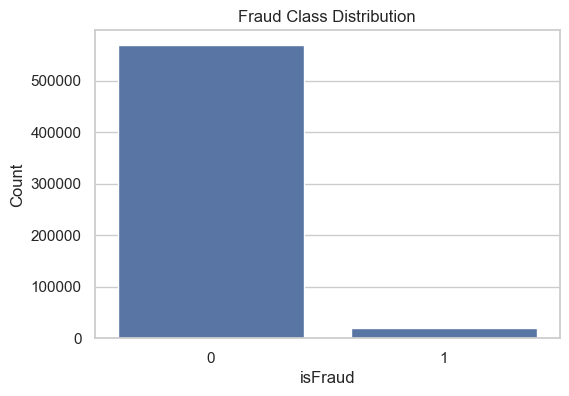

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Fraud Class Distribution")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

**Interpretation**  
The target distribution is imbalanced, with fraudulent transactions representing a much smaller share of the dataset than legitimate transactions. This means model evaluation should focus on metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

## Missing Value Analysis
Many variables in this dataset contain substantial missingness, especially identity-related and engineered features. This section quantifies missing data to guide future preprocessing decisions.

In [39]:
# =========================================
# 5. Missing value analysis
# =========================================
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_df = missing_ratio.reset_index()
missing_df.columns = ["column", "missing_ratio"]

missing_df.head(30)

,column,missing_ratio
0,id_24,0.9920
1,id_25,0.9913
2,id_07,0.9913
3,id_08,0.9913
4,id_21,0.9913
5,id_26,0.9913
6,id_27,0.9912
7,id_23,0.9912
8,id_22,0.9912
9,dist2,0.9363


In [40]:
high_missing = missing_df[missing_df["missing_ratio"] > 0.50]

print(f"Columns with >50% missing values: {high_missing.shape[0]}")
high_missing.head(30)

Columns with >50% missing values: 214


,column,missing_ratio
0,id_24,0.9920
1,id_25,0.9913
2,id_07,0.9913
3,id_08,0.9913
4,id_21,0.9913
5,id_26,0.9913
6,id_27,0.9912
7,id_23,0.9912
8,id_22,0.9912
9,dist2,0.9363


### Interpretation

Missingness is a major characteristic of this dataset. Several identity-related variables, such as `id_24`, `id_25`, `id_07`, and `id_08`, are missing in more than **99%** of records. Overall, **214 columns** have more than **50% missing values**.

- \>95% missing: strong candidates for removal
- 50%–95% missing: evaluate signal before dropping
- consider missingness indicators for selected fields.

This has important implications for preprocessing. Features with extremely high sparsity may need to be dropped, while others may still retain predictive value if their missingness itself is informative. Rather than treating all nulls as noise, the preprocessing stage should explicitly evaluate whether missingness carries fraud signal.

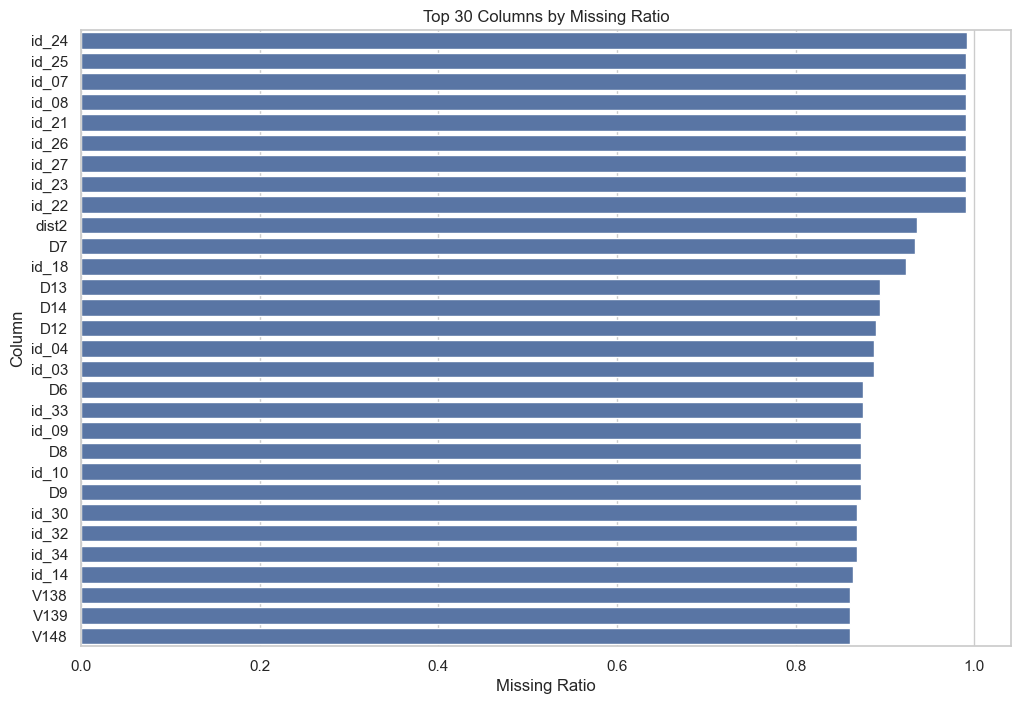

In [41]:
plt.figure(figsize=(12, 8))
sns.barplot(data=high_missing.head(30), x="missing_ratio", y="column")
plt.title("Top 30 Columns by Missing Ratio")
plt.xlabel("Missing Ratio")
plt.ylabel("Column")
plt.show()

**Interpretation**  
A large number of features have very high missingness. These columns may require one of the following in later preprocessing:
- removal if sparsity is extreme
- imputation if the feature still has signal
- missing-value indicators where null patterns may themselves be predictive

## Feature Groups
To structure the analysis, it is useful to separate numerical and categorical variables and identify known feature families such as `V`, `D`, `C`, `M`, and `id_`.

In [42]:
# =========================================
# 6. Feature groups
# =========================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numeric columns: 403
Number of categorical columns: 31


In [43]:
v_cols = [col for col in df.columns if col.startswith("V")]
d_cols = [col for col in df.columns if col.startswith("D")]
c_cols = [col for col in df.columns if col.startswith("C")]
m_cols = [col for col in df.columns if col.startswith("M")]
id_cols = [col for col in df.columns if col.startswith("id_")]

print(f"V columns: {len(v_cols)}")
print(f"D columns: {len(d_cols)}")
print(f"C columns: {len(c_cols)}")
print(f"M columns: {len(m_cols)}")
print(f"id_ columns: {len(id_cols)}")

V columns: 339
D columns: 17
C columns: 14
M columns: 9
id_ columns: 38


### Interpretation

The dataset is dominated by numeric variables, with **403 numeric features** and **31 categorical features**. A large share of the numeric space is made up of engineered anonymized features, particularly the **339 `V` columns**, alongside additional groups such as `D`, `C`, `M`, and `id_` variables.

This structure suggests that feature selection and feature importance analysis will be especially important later in the project. Because many variables are anonymized, model interpretation will likely rely more on relative predictive importance than on direct business meaning for every single feature.

## Categorical Feature Cardinality Analysis

Understanding the **cardinality** of the categorical variables(the number of unique categories each variable contains) helps in choosing an encoding strategy. 

Different encoding strategies are appropriate depending on cardinality:

-   Low cardinality (≤10 categories)
    -    One-hot encoding works well.

- Medium cardinality (10–50 categories)
    - Frequency encoding or target encoding may be more efficient.

- High cardinality (>50 categories)
    - Label encoding or frequency encoding is often preferred to avoid creating extremely large feature spaces.

This analysis helps guide the preprocessing decisions in the modeling stage.

In [44]:
# =========================================
# 7. Categorical Cardinality
# =========================================

categorical_cols = df.select_dtypes(exclude=[np.number]).columns

cardinality = (
    df[categorical_cols]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

cardinality_df = cardinality.reset_index()
cardinality_df.columns = ["feature", "unique_values"]

cardinality_df

,feature,unique_values
0,DeviceInfo,1786
1,id_33,260
2,id_31,130
3,id_30,75
4,R_emaildomain,60
5,P_emaildomain,59
6,ProductCD,5
7,card6,4
8,card4,4
9,id_34,4


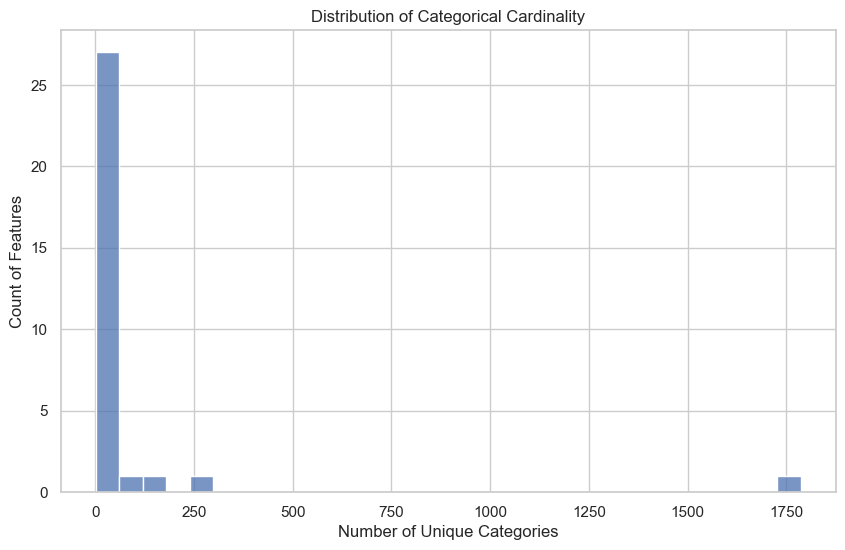

In [45]:
plt.figure(figsize=(10,6))
sns.histplot(cardinality_df["unique_values"], bins=30)
plt.title("Distribution of Categorical Cardinality")
plt.xlabel("Number of Unique Categories")
plt.ylabel("Count of Features")
plt.show()

In [46]:
low_card = cardinality[cardinality <= 10]
medium_card = cardinality[(cardinality > 10) & (cardinality <= 50)]
high_card = cardinality[cardinality > 50]

print("Low cardinality features:", len(low_card))
print("Medium cardinality features:", len(medium_card))
print("High cardinality features:", len(high_card))

Low cardinality features: 25
Medium cardinality features: 0
High cardinality features: 6


In [47]:
print("\nLow cardinality:")
display(low_card)

print("\nMedium cardinality:")
display(medium_card)

print("\nHigh cardinality:")
display(high_card)


Low cardinality:


ProductCD     5
card6         4
card4         4
id_34         4
id_15         3
M4            3
id_23         3
M2            2
M1            2
id_12         2
M9            2
M8            2
M7            2
M6            2
M5            2
M3            2
id_27         2
id_28         2
id_29         2
id_16         2
id_35         2
id_36         2
id_37         2
id_38         2
DeviceType    2
dtype: int64


Medium cardinality:


Series([], dtype: int64)


High cardinality:


DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
dtype: int64

### Cardinality Analysis Summary

The categorical feature cardinality analysis reveals a clear structure across the dataset.

Most categorical variables fall into the **low-cardinality category**, with **25 features containing 10 or fewer unique values**. These include variables such as `ProductCD`, `card4`, `card6`, `DeviceType`, and several `M` and `id_` indicator variables. Because these variables contain only a small number of categories, they are well suited for **one-hot encoding** during the preprocessing stage.

Interestingly, **no variables fall into the medium-cardinality range (10–50 categories)**. This means the dataset does not contain categorical features that require intermediate strategies such as target encoding or frequency encoding.

However, **six variables exhibit high cardinality**, including:

- `DeviceInfo` (1786 unique values)
- `id_33` (260 unique values)
- `id_31` (130 unique values)
- `id_30` (75 unique values)
- `R_emaildomain` (60 unique values)
- `P_emaildomain` (59 unique values)

These features contain a large number of distinct categories and would create extremely wide feature matrices if one-hot encoded. For these variables, more efficient encoding approaches such as **label encoding, frequency encoding, or grouping rare categories** will be more appropriate.

Overall, the dataset is dominated by **low-cardinality categorical variables**, which simplifies preprocessing for most features. Only a small subset of high-cardinality variables will require special handling in the modeling pipeline.

### Planned Encoding Strategy for Modeling

Based on the cardinality analysis, the following encoding strategy will be used in the modeling stage:

Low cardinality features (≤10 categories)  
• One-hot encoding

High cardinality features (>50 categories)  
• Label encoding or frequency encoding

This approach ensures that categorical variables are encoded efficiently while avoiding unnecessary expansion of the feature space.

## Transaction Amount Analysis
Transaction amount is one of the most intuitive variables in fraud detection. This section explores its distribution overall and by fraud class.

In [48]:
# =========================================
# 8. Transaction amount analysis
# =========================================
df["TransactionAmt"].describe()

count   590,540.0000
mean        135.0272
std         239.1625
min           0.2510
25%          43.3210
50%          68.7690
75%         125.0000
max      31,937.3910
Name: TransactionAmt, dtype: float64

In [49]:
df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"569,877.0000",134.5117,239.3951,0.2510,43.9700,68.5000,120.0000,"31,937.3910"
1,"20,663.0000",149.2448,232.2122,0.2920,35.0440,75.0000,161.0000,"5,191.0000"


### Interpretation

`TransactionAmt` is strongly right-skewed, with a median of **68.77** and a maximum value above **31,000**, indicating the presence of large outliers. Fraudulent transactions tend to be somewhat larger on average than legitimate ones, with a fraud mean of **149.24** versus **134.51** for non-fraud transactions.

The difference is more noticeable in the upper part of the distribution: the 75th percentile for fraud is **161**, compared with **120** for legitimate transactions. This suggests that transaction amount may carry predictive signal, although it is unlikely to be sufficient on its own and will probably be more useful when combined with other behavioral or identity features.

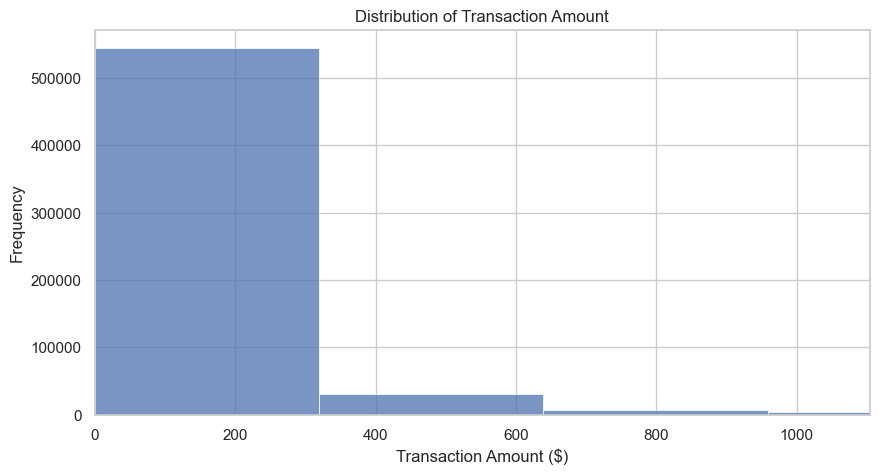

In [50]:
# Plot the Distribution of Transaction Amount
plt.figure(figsize=(10, 5))
sns.histplot(df["TransactionAmt"], bins=100)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")
plt.xlim(0, df["TransactionAmt"].quantile(0.99))
plt.show()

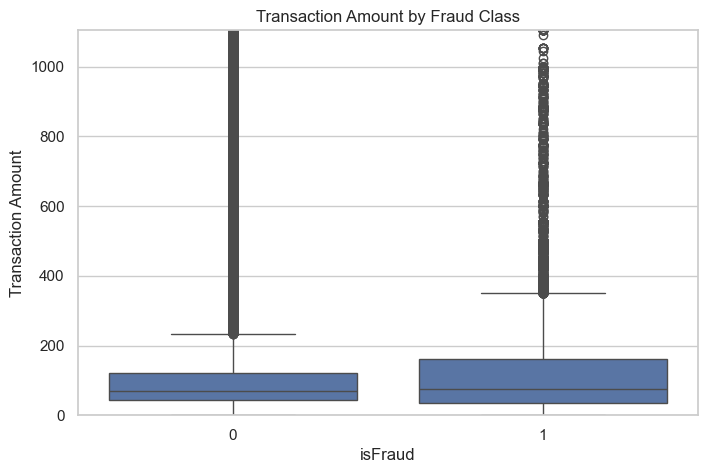

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="isFraud", y="TransactionAmt")
plt.title("Transaction Amount by Fraud Class")
plt.xlabel("isFraud")
plt.ylabel("Transaction Amount")
plt.ylim(0, df["TransactionAmt"].quantile(0.99))
plt.show()

### Interpretation  
`TransactionAmt` is strongly right-skewed, with a small number of very large transactions stretching the upper tail. This makes a log transformation useful for stabilizing the distribution and improving comparability across transactions.

In [52]:
df["log_TransactionAmt"] = np.log1p(df["TransactionAmt"])

In [53]:
df.groupby("isFraud")["log_TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"569,877.0000",4.3833,0.9305,0.2239,3.8060,4.2413,4.7958,10.3716
1,"20,663.0000",4.3742,1.1049,0.2562,3.5847,4.3307,5.0876,8.5549


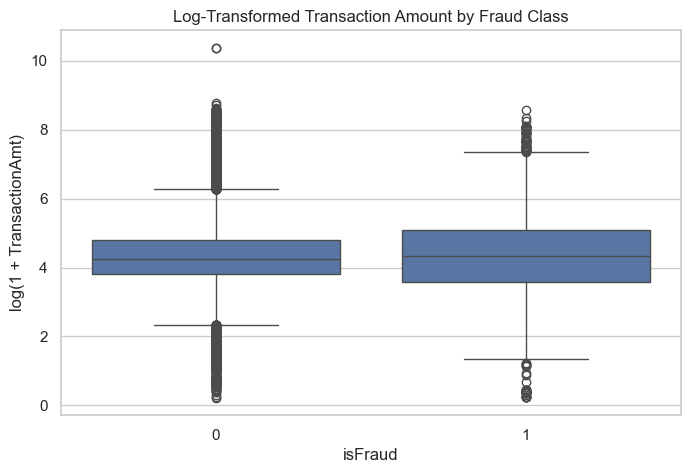

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="isFraud", y="log_TransactionAmt")
plt.title("Log-Transformed Transaction Amount by Fraud Class")
plt.xlabel("isFraud")
plt.ylabel("log(1 + TransactionAmt)")
plt.show()

### Interpretation of Raw vs Log-Transformed Transaction Amount

The raw `TransactionAmt` variable is highly right-skewed, with a small number of very large transactions inflating the mean. In raw scale, fraudulent transactions appear slightly larger on average than legitimate ones, with a higher mean and higher upper quartile.

After applying `log(1 + TransactionAmt)`, the distribution becomes more compressed and easier to compare across classes. The transformed summaries show that the difference between fraud and non-fraud is more modest than the raw means initially suggest. In particular, the fraud median remains slightly higher, but the class means become very similar.

This indicates that transaction amount alone may contain some fraud signal, especially in the upper part of the distribution, but its effect is not likely to be strong in isolation.

## Transaction Time Analysis
`TransactionDT` is not a standard timestamp, but it still captures the timing of transactions and may reveal useful fraud patterns over time.

In [55]:
# =========================================
# 8. Time-related analysis
# =========================================
df["TransactionDT"].describe()

count      590,540.0000
mean     7,372,311.3101
std      4,617,223.6465
min         86,400.0000
25%      3,027,057.7500
50%      7,306,527.5000
75%     11,246,620.0000
max     15,811,131.0000
Name: TransactionDT, dtype: float64

### Interpretation

`TransactionDT` spans a wide range, indicating that the dataset covers a substantial transaction window over time. Although this variable is not a direct calendar timestamp, it can still capture meaningful temporal structure such as changing fraud intensity, seasonality, campaign behavior, or shifts in user activity patterns.

This makes time-aware feature engineering a promising next step

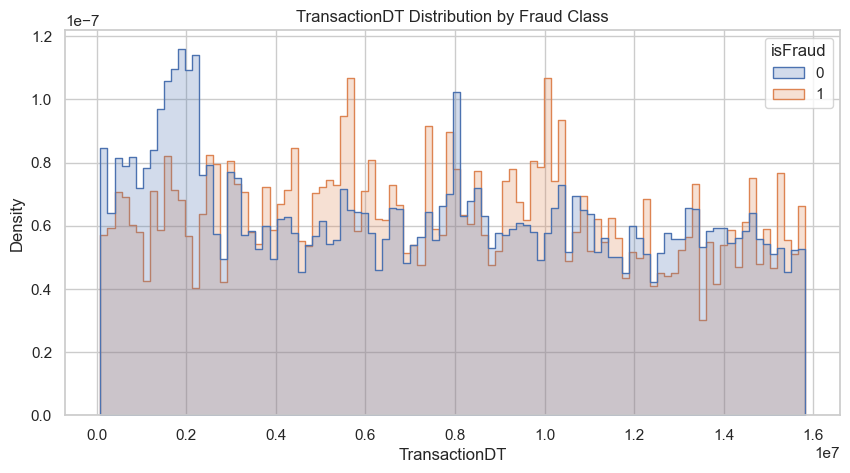

In [56]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="TransactionDT",
    hue="isFraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("TransactionDT Distribution by Fraud Class")
plt.xlabel("TransactionDT")
plt.ylabel("Density")
plt.show()

**Interpretation**  
Temporal differences between fraud and legitimate transactions may indicate changing attack intensity, fraud campaigns, or time-based usage patterns.

## Selected Categorical Feature Analysis
This section explores a small set of meaningful categorical features that may show different fraud rates across categories.

In [57]:
# =========================================
# 9. Selected categorical feature analysis
# =========================================
cat_features = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType"]

for col in cat_features:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(10))


--- ProductCD ---
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

--- card4 ---
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

--- card6 ---
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

--- P_emaildomain ---
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
Name: count, dtype: int64

--- R_emaildomain ---
R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com         11842
aol.com            3701
outlook.com        2507
comcast.net       

### Interpretation

The categorical variables show strong concentration in a small number of dominant categories. For example, `ProductCD = W` accounts for the majority of transactions, `visa` and `mastercard` dominate `card4`, and `debit` dominates `card6`.

Some variables also exhibit significant missingness, especially `R_emaildomain` and `DeviceType`. This reinforces an important point for the preprocessing stage: categorical features should not only be encoded, but also assessed for whether missing categories or rare levels carry meaningful fraud signal. In fraud detection, sparse or unusual category patterns can sometimes be highly informative.

In [58]:
for col in ["ProductCD", "card4", "card6", "DeviceType"]:
    if col in df.columns:
        fraud_rate = df.groupby(col)["isFraud"].mean().sort_values(ascending=False)
        print(f"\nFraud rate by {col}:")
        print(fraud_rate.head(10))


Fraud rate by ProductCD:
ProductCD
C   0.1169
S   0.0590
H   0.0477
R   0.0378
W   0.0204
Name: isFraud, dtype: float64

Fraud rate by card4:
card4
discover           0.0773
visa               0.0348
mastercard         0.0343
american express   0.0287
Name: isFraud, dtype: float64

Fraud rate by card6:
card6
credit            0.0668
debit             0.0243
charge card       0.0000
debit or credit   0.0000
Name: isFraud, dtype: float64

Fraud rate by DeviceType:
DeviceType
mobile    0.1017
desktop   0.0652
Name: isFraud, dtype: float64


In [59]:
def plot_fraud_rate_by_category(data, col, top_n=10):
    top_categories = data[col].value_counts(dropna=False).head(top_n).index
    subset = data[data[col].isin(top_categories)]

    fraud_rate = subset.groupby(col)["isFraud"].mean().sort_values(ascending=False)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=fraud_rate.index.astype(str), y=fraud_rate.values)
    plt.title(f"Fraud Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Fraud Rate")
    plt.xticks(rotation=45)
    plt.show()

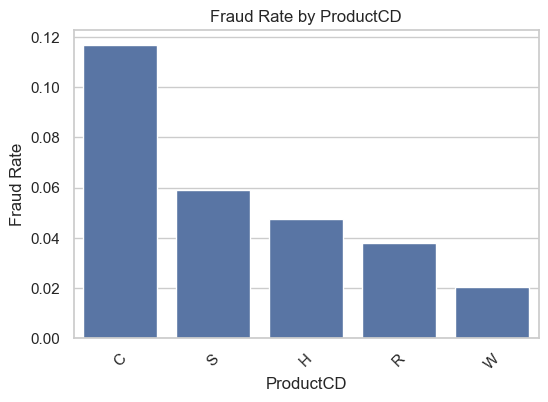

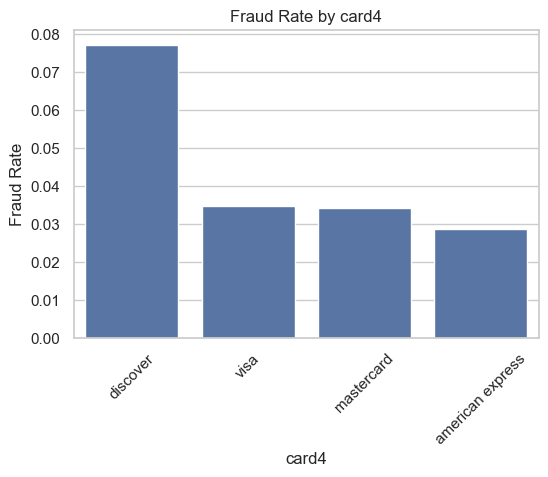

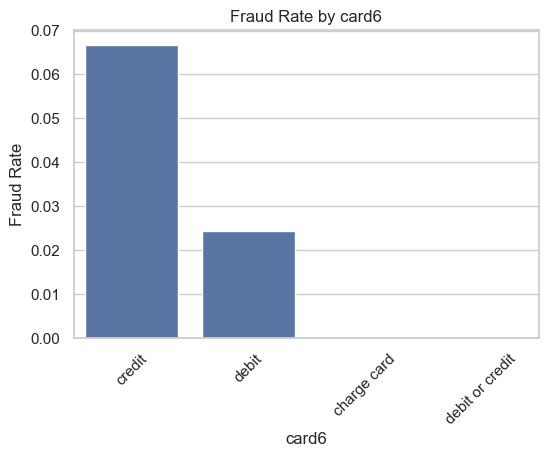

In [60]:
for col in ["ProductCD", "card4", "card6"]:
    if col in df.columns:
        plot_fraud_rate_by_category(df, col)

**Interpretation**  
Differences in fraud rate across card type, product type, or device-related categories may reflect operational risk patterns. These features may become strong predictors after encoding.

## Selected Numerical Feature Analysis
This section compares a few relevant numerical variables across fraud and non-fraud classes.

In [61]:
# =========================================
# 10. Selected numerical feature analysis
# =========================================
num_features = ["TransactionAmt", "dist1", "dist2", "C1", "C5", "D1", "D4"]

for col in num_features:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df.groupby("isFraud")[col].describe())


--- TransactionAmt ---
               count     mean      std    min     25%     50%      75%  \
isFraud                                                                  
0       569,877.0000 134.5117 239.3951 0.2510 43.9700 68.5000 120.0000   
1        20,663.0000 149.2448 232.2122 0.2920 35.0440 75.0000 161.0000   

                max  
isFraud              
0       31,937.3910  
1        5,191.0000  

--- dist1 ---
               count     mean      std    min    25%     50%     75%  \
isFraud                                                                
0       233,514.0000 117.3601 370.6419 0.0000 3.0000  8.0000 24.0000   
1         4,755.0000 174.5889 424.2323 0.0000 3.0000 10.0000 85.5000   

                max  
isFraud              
0       10,286.0000  
1        4,942.0000  

--- dist2 ---
              count     mean      std    min    25%     50%      75%  \
isFraud                                                                
0       33,896.0000 235.1998 536.7985 0.

### Interpretation

Several numerical features show noticeable differences between fraudulent and legitimate transactions. In particular, fraud cases have a higher average `dist1` and substantially higher average `C1`, while features such as `C5`, `D1`, and `D4` tend to be lower among fraud cases.

These differences suggest that some behavioral or engineered variables may separate fraud from legitimate activity more clearly than raw transaction amount alone. However, because some of these features are also sparse or anonymized, their usefulness should ultimately be validated through model-based importance and out-of-sample performance rather than descriptive statistics alone.

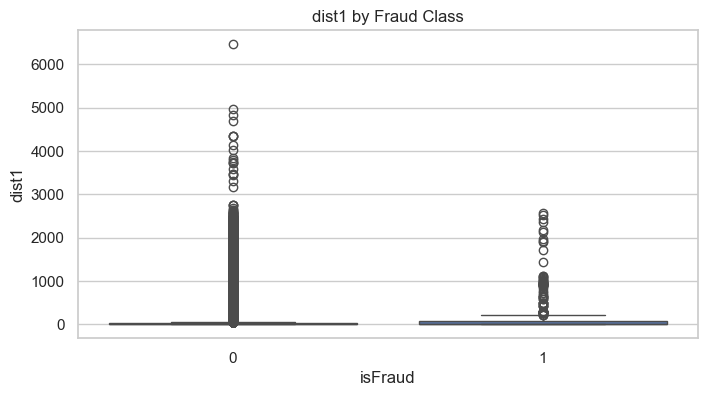

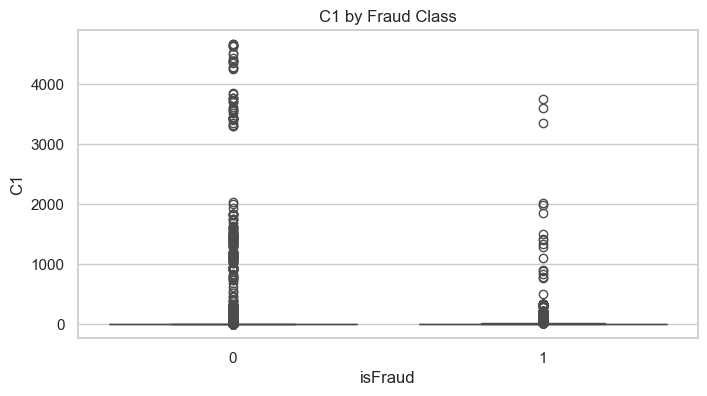

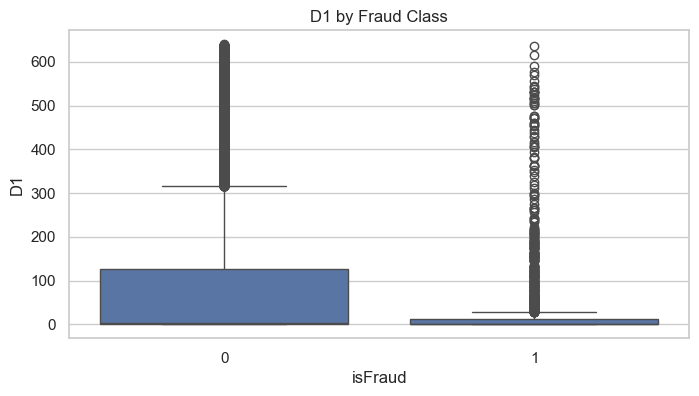

In [62]:
for col in ["dist1", "C1", "D1"]:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(
            data=df.sample(min(50000, len(df)), random_state=42),
            x="isFraud",
            y=col
        )
        plt.title(f"{col} by Fraud Class")
        plt.show()

## Correlation Analysis
Because the dataset has many features, a focused correlation analysis is more useful than plotting a full matrix across all columns.

,isFraud,TransactionAmt,log_TransactionAmt,dist1,C1,C5,D1,D4
isFraud,1.0000,0.0113,-0.0018,0.0215,0.0306,-0.0308,-0.0672,-0.0672
TransactionAmt,0.0113,1.0000,0.7071,0.0261,-0.0177,-0.0306,-0.0400,-0.0503
log_TransactionAmt,-0.0018,0.7071,1.0000,0.0295,-0.0289,-0.0147,0.0166,0.0296
dist1,0.0215,0.0261,0.0295,1.0000,-0.0214,-0.0201,-0.0443,-0.0377
C1,0.0306,-0.0177,-0.0289,-0.0214,1.0000,0.1659,0.0057,0.0061
C5,-0.0308,-0.0306,-0.0147,-0.0201,0.1659,1.0000,0.1320,0.1456
D1,-0.0672,-0.0400,0.0166,-0.0443,0.0057,0.1320,1.0000,0.5857
D4,-0.0672,-0.0503,0.0296,-0.0377,0.0061,0.1456,0.5857,1.0000


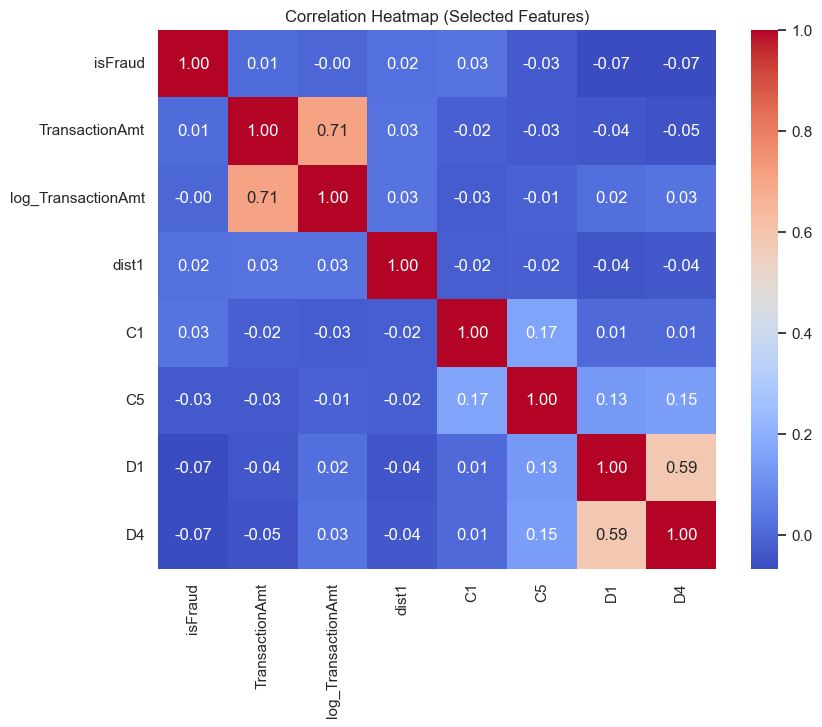

In [63]:
# =========================================
# 11. Correlation analysis
# =========================================
selected_corr_cols = [
    "isFraud",
    "TransactionAmt",
    "log_TransactionAmt",
    "dist1",
    "C1",
    "C5",
    "D1",
    "D4"
]
selected_corr_cols = [col for col in selected_corr_cols if col in df.columns]

corr = df[selected_corr_cols].corr()

display(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [64]:
spearman_corr = df[selected_corr_cols].corr(method="spearman")
display(spearman_corr)

,isFraud,TransactionAmt,log_TransactionAmt,dist1,C1,C5,D1,D4
isFraud,1.0000,-0.0016,-0.0016,0.0208,0.0786,-0.1054,-0.0640,-0.0587
TransactionAmt,-0.0016,1.0000,1.0000,0.0082,-0.0363,0.0542,0.0196,0.0467
log_TransactionAmt,-0.0016,1.0000,1.0000,0.0082,-0.0363,0.0542,0.0196,0.0467
dist1,0.0208,0.0082,0.0082,1.0000,-0.0310,-0.0672,-0.0750,-0.0588
C1,0.0786,-0.0363,-0.0363,-0.0310,1.0000,0.4562,0.3387,0.4714
C5,-0.1054,0.0542,0.0542,-0.0672,0.4562,1.0000,0.3200,0.2754
D1,-0.0640,0.0196,0.0196,-0.0750,0.3387,0.3200,1.0000,0.6622
D4,-0.0587,0.0467,0.0467,-0.0588,0.4714,0.2754,0.6622,1.0000


### Interpretation of Spearman Correlation

The Spearman correlation results reveal slightly stronger relationships with the fraud target than the Pearson analysis suggested.

The most notable associations with `isFraud` are:

- `C5` (-0.105)
- `C1` (0.079)
- `D1` (-0.064)
- `D4` (-0.059)

Although these correlations are still relatively small, they are noticeably larger than the corresponding Pearson correlations. This suggests that some variables may have **monotonic but nonlinear relationships** with fraud risk.

For example, the negative relationship between `C5` and fraud may indicate that certain behavioral counts decrease as fraud probability increases. Similarly, the positive relationship between `C1` and fraud suggests that higher values of this variable may be associated with elevated fraud risk.

Overall, the Spearman results reinforce the idea that fraud patterns are subtle and distributed across multiple variables rather than dominated by a single strongly predictive feature.

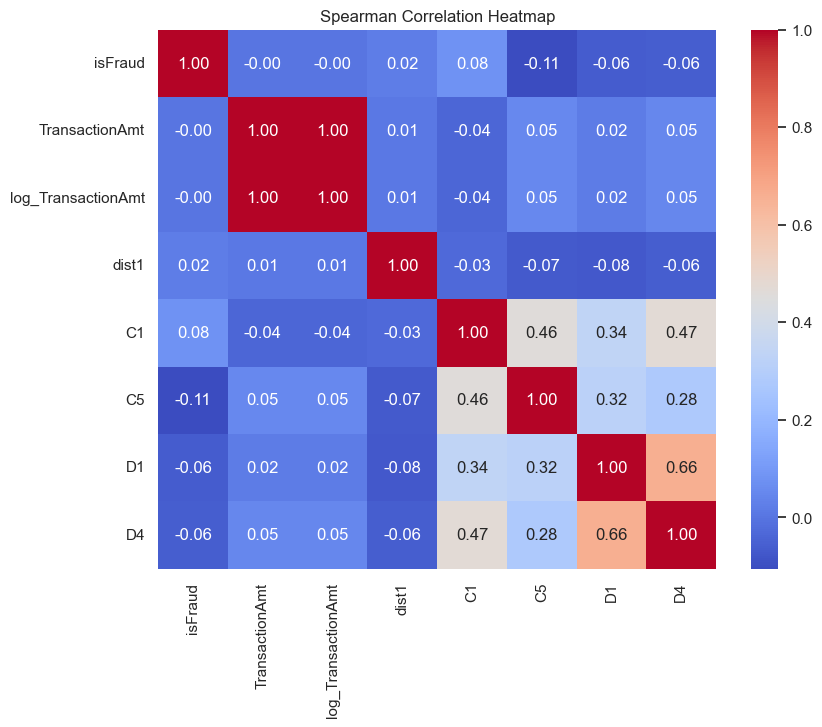

In [65]:
plt.figure(figsize=(9,7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Correlation Heatmap")
plt.show()

### Relationships Between Predictors (Spearman)

Several moderate correlations appear between predictor variables, particularly among the `C` and `D` feature groups.

Examples include:

- `D1` and `D4` (0.66)
- `C1` and `D4` (0.47)
- `C1` and `C5` (0.46)
- `C1` and `D1` (0.34)

These relationships suggest that some engineered behavioral features may capture related aspects of transaction activity.

However, these correlations are not problematic for tree-based models such as Random Forest, Gradient Boosting, or XGBoost, which are generally robust to multicollinearity. Instead, these patterns may help models identify combinations of features that signal suspicious transaction behavior. 

### Correlation Analysis Summary

Both Pearson and Spearman correlation analyses show that no single variable has a strong direct relationship with the fraud target.

This is typical for fraud detection datasets. Fraud behavior is usually driven by **complex interactions between multiple variables**, rather than strong linear relationships with individual features.

The correlation analysis therefore serves primarily as an exploratory tool to:

- identify potential nonlinear relationships
- detect redundancy among predictors
- guide feature engineering and model selection

In the next stage of the project, feature preprocessing and model training will focus on capturing multivariate patterns using algorithms capable of modeling nonlinear relationships.

## Missingness as Signal
In fraud detection, whether a field is missing can itself be predictive. This section checks whether missingness in selected variables is associated with different fraud rates.

In [66]:
# =========================================
# 12. Missingness as signal
# =========================================
selected_missing_cols = ["DeviceType", "dist1", "dist2", "id_30", "id_31"]

for col in selected_missing_cols:
    if col in df.columns:
        temp = df[col].isnull().astype(int)
        fraud_rate_missing = df.groupby(temp)["isFraud"].mean()
        print(f"\nFraud rate by missingness for {col}:")
        print(fraud_rate_missing)


Fraud rate by missingness for DeviceType:
DeviceType
0   0.0796
1   0.0210
Name: isFraud, dtype: float64

Fraud rate by missingness for dist1:
dist1
0   0.0200
1   0.0452
Name: isFraud, dtype: float64

Fraud rate by missingness for dist2:
dist2
0   0.0992
1   0.0306
Name: isFraud, dtype: float64

Fraud rate by missingness for id_30:
id_30
0   0.0444
1   0.0336
Name: isFraud, dtype: float64

Fraud rate by missingness for id_31:
id_31
0   0.0796
1   0.0211
Name: isFraud, dtype: float64


### Interpretation

Missingness appears to carry meaningful fraud signal for several variables. For example, transactions where `DeviceType` is present have a much higher fraud rate than those where it is missing (**7.96% vs 2.10%**). A similar pattern appears for `id_31`. By contrast, `dist1` shows the opposite behavior, where missing values are associated with a higher fraud rate than observed values.

This is an important finding. In fraud detection, null patterns are often not random and may reflect differences in device visibility, transaction context, or data collection pathways. As a result, missing-value indicators should be considered as part of the feature engineering strategy rather than treating missingness as a purely technical nuisance.

## Initial Fraud-Risk Observations

Based on the exploratory analysis:

- the target is imbalanced, confirming that fraud is a rare-event problem
- many features have substantial missingness and will require careful treatment
- transaction amount appears to behave differently across fraud classes
- selected categorical variables show different fraud rates across categories
- missingness itself may carry predictive signal

These observations will directly influence preprocessing, feature engineering, and model evaluation decisions.